# 07 — Value Function Approximation

This notebook explains **why value function approximation (VFA) is needed, where its equations come from, how the weights are learned, how those weights produce state values and state-action values, and why this can use far less memory than a lookup table**.

The notebook first develops every important equation by hand. A complete numerical example then follows one transition from features → predicted Q-values → target → loss → gradient → weight update → new Q-value → value estimate for an unseen state. After that, the same idea is applied to **Approximate Q-Learning, Approximate SARSA, and Approximate Expected SARSA** on `MountainCar-v0`.

### Learning goals

By the end, you should be able to answer:

1. Why does a Q-table become a problem for large or continuous state spaces?
2. What does **parameterization** mean?
3. What are **features** and **weights**?
4. Why do we often write the loss as $\frac{1}{2}(y-\hat Q)^2$?
5. How do we derive the update $\mathbf w \leftarrow \mathbf w+\alpha\delta\nabla_{\mathbf w}\hat Q$?
6. How is each individual weight updated?
7. How do learned weights produce $\hat V(s)$ or $\hat Q(s,a)$?
8. How can VFA estimate values for states that were never stored?
9. How do Q-Learning, SARSA, and Expected SARSA differ under function approximation?

## 1. From Tabular Reinforcement Learning to Function Approximation

In earlier tabular methods, every state or state-action pair had its own stored value.

For a state-value table:

$$V(s)=\text{one stored number for state }s$$

For an action-value table:

$$Q(s,a)=\text{one stored number for every state-action pair }(s,a)$$

If there are $|\mathcal S|$ states and $|\mathcal A|$ actions, a Q-table stores:

$$\boxed{|\mathcal S|\times|\mathcal A|\text{ values}}$$

This works well for a small discrete problem such as Taxi. It becomes difficult when the state space is very large, and it becomes impossible to enumerate exactly when state variables are continuous.

In [ ]:
import numpy as np
import pandas as pd

def q_table_memory(bins_per_dimension, n_actions=3, bytes_per_value=8):
    n_states = bins_per_dimension**2
    n_q_values = n_states * n_actions
    memory_bytes = n_q_values * bytes_per_value
    return n_states, n_q_values, memory_bytes

rows = []
for bins in [100, 1_000, 10_000]:
    n_states, n_q_values, memory_bytes = q_table_memory(bins)
    rows.append({
        "Bins per state dimension": f"{bins:,}",
        "Discrete states": f"{n_states:,}",
        "Q-values for 3 actions": f"{n_q_values:,}",
        "float64 memory": f"{memory_bytes / 1024**2:,.2f} MiB"
    })

pd.DataFrame(rows)

,Bins per state dimension,Discrete states,Q-values for 3 actions,float64 memory
0,100,"10,000","30,000",0.23 MiB
1,"1,000","1,000,000","3,000,000",22.89 MiB
2,"10,000","100,000,000","300,000,000","2,288.82 MiB"


The table above assumes only **two state variables** and three actions. Increasing the resolution from 100 bins to 10,000 bins per state variable changes the number of state combinations from $10^4$ to $10^8$.

For 10,000 bins in each of two state dimensions:

$$|\mathcal S|=10{,}000\times10{,}000=100{,}000{,}000$$

$$\text{Q-table entries}=100{,}000{,}000\times3=300{,}000{,}000$$

$$\text{Memory}=300{,}000{,}000\times8=2{,}400{,}000{,}000\text{ bytes}\approx2.24\text{ GiB}$$

That is still only a discretization. A continuous state variable can take infinitely many possible values in theory, so an exact table cannot contain every possible state.

The main idea of value function approximation is therefore:

$$\boxed{\text{Store one value for every state-action pair}\quad\longrightarrow\quad\text{learn parameters that calculate values}}$$

## 2. What Does Parameterization Mean?

A **parameterized function** has a fixed mathematical form but contains adjustable parameters.

Consider:

$$f(x;w)=w\sin(x)$$

The input is $x$ and the parameter is $w$. We do not store the output for every possible $x$. We store $w$ and calculate the output whenever an input is given.

For example:

$$f(x;1)=1\sin(x)$$

$$f(x;2)=2\sin(x)$$

$$f(x;3)=3\sin(x)$$

The same idea is used in reinforcement learning.

Instead of storing the exact state value:

$$V_\pi(s)$$

we approximate it using parameters $\mathbf w$:

$$\boxed{V_\pi(s)\approx\hat V(s;\mathbf w)}$$

Instead of storing every exact state-action value:

$$Q_\pi(s,a)$$

we approximate it using parameters:

$$\boxed{Q_\pi(s,a)\approx\hat Q(s,a;\mathbf w)}$$

The hat in $\hat V$ or $\hat Q$ means **estimated/approximated value**.

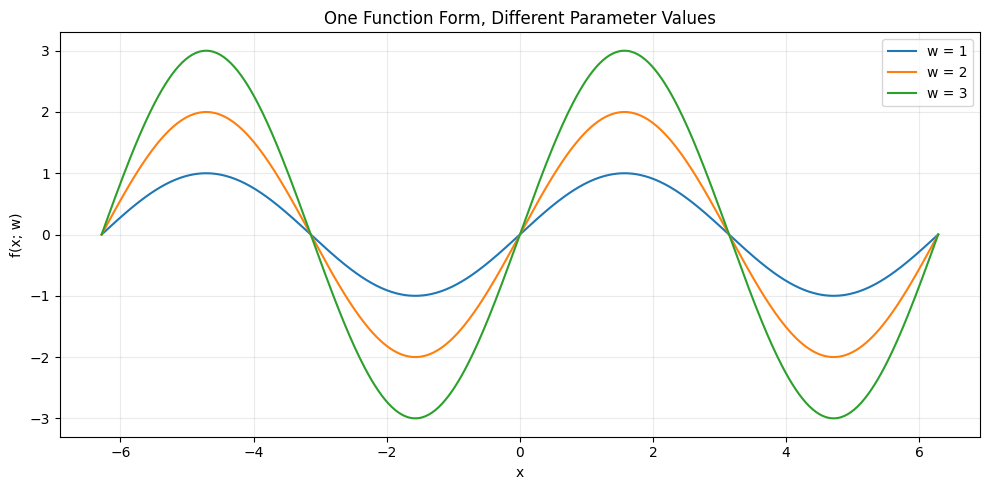

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-2*np.pi, 2*np.pi, 500)
plt.figure(figsize=(10, 5))
for w in [1, 2, 3]:
    plt.plot(x, w*np.sin(x), label=f"w = {w}")
plt.xlabel("x")
plt.ylabel("f(x; w)")
plt.title("One Function Form, Different Parameter Values")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3. States Become Features

A function approximator usually does not treat a state as a table index. Instead, the state is represented by a set of numerical **features**.

Suppose a state contains $n$ features:

$$\mathbf x(s)=[x_1(s),x_2(s),\ldots,x_n(s)]^T$$

For MountainCar, the raw state contains:

$$s=[\text{position},\text{velocity}]$$

We may use the raw variables directly or transform them into a richer feature vector such as polynomial features, radial-basis features, tile-coded features, or neural-network features.

A feature tells the model something about the current state. A **weight** tells the model how strongly that feature should influence the estimated value.

## 4. Linear State-Value Approximation

For a linear approximator:

$$\boxed{\hat V(s;\mathbf w)=\mathbf w^T\mathbf x(s)}$$

Written term by term:

$$\hat V(s;\mathbf w)=w_1x_1(s)+w_2x_2(s)+\cdots+w_nx_n(s)$$

A single vector $\mathbf w$ can therefore generate value estimates for many different states.

### Small state-value example

Suppose:

$$\mathbf x(s)=[1,-0.4,0.3,0.16,-0.12]^T$$

and:

$$\mathbf w=[-0.8,0.2,0.5,-0.1,0.3]^T$$

Then:

$$\hat V(s)=(-0.8)(1)+(0.2)(-0.4)+(0.5)(0.3)+(-0.1)(0.16)+(0.3)(-0.12)=-0.782$$

The value $-0.782$ did not need to be stored in a table. It was **calculated from the features and weights**.

## 5. Linear State-Action Value Approximation

For action values we need both the state and the action.

One common representation for a discrete action space is to keep one weight vector for each action:

$$\boxed{\hat Q(s,a;\mathbf W)=\mathbf w_a^T\boldsymbol\phi(s)}$$

If there are three actions and five features, the parameter matrix is:

$$\mathbf W=
\begin{bmatrix}
\mathbf w_0^T\\
\mathbf w_1^T\\
\mathbf w_2^T
\end{bmatrix}$$

Only $3\times5=15$ weights are stored in this example. Every Q-value is calculated from those weights.

For a given state, calculate all action values:

$$\hat Q(s,0)=\mathbf w_0^T\boldsymbol\phi(s)$$

$$\hat Q(s,1)=\mathbf w_1^T\boldsymbol\phi(s)$$

$$\hat Q(s,2)=\mathbf w_2^T\boldsymbol\phi(s)$$

For greedy control:

$$\boxed{a^*=\arg\max_a\hat Q(s,a)}$$

and the greedy estimate of the state value is:

$$\boxed{\hat V_*(s)=\max_a\hat Q(s,a)}$$

For a stochastic policy $\pi$:

$$\boxed{\hat V_\pi(s)=\sum_a\pi(a|s)\hat Q(s,a)}$$

# Part I — Where Do the Learning Equations Come From?

This section derives the weight-update equation instead of simply stating it.

## 6. What Are the Weights and How Are They Obtained?

The weights are **learnable parameters**. They are not usually known before training.

A typical sequence is:

1. Initialize the weights, often with zeros or small values.
2. Observe a transition.
3. Use the current weights to make a prediction.
4. Construct a target.
5. Measure the prediction error.
6. Change the weights to reduce that error.
7. Repeat over many transitions.

For a linear action-value function:

$$\hat Q(s,a;\mathbf w_a)=\mathbf w_a^T\boldsymbol\phi(s)$$

the goal is to adjust $\mathbf w_a$ so that the predictions become closer to useful TD targets.

In supervised linear regression with fixed targets, a closed-form least-squares solution may sometimes be available. In temporal-difference reinforcement learning, however, the target itself is repeatedly generated from rewards and current value estimates. For this reason, online gradient updates are commonly used.

## 7. Prediction, Target, Error, and Loss

Before defining the error and loss, it is important to understand where the **prediction** and the **target** come from.

The environment still provides a state. Value function approximation does not remove the state. Instead, the state is converted into a feature representation before it is given to the approximator.

For example, suppose the environment gives the current state:

$$S_t=[\text{position},\text{velocity}]$$

We can also write:

$$S_t=[p,v]$$

where $p$ is position and $v$ is velocity.

### State Variables and Features Are Not the Same Thing

The state above has only **two elements**:

$$S_t=[p,v]$$

but the feature vector can contain more than two elements.

A feature function can create new quantities from the original state variables:

$$\boxed{\boldsymbol\phi(S_t)=[\phi_1(S_t),\phi_2(S_t),\ldots,\phi_m(S_t)]^T}$$

For this example, choose:

$$\boxed{\boldsymbol\phi(S_t)=[1,p,v,p^2,pv]^T}$$

So the two original state variables are transformed into five features:

$$\phi_1(S_t)=1$$

$$\phi_2(S_t)=p$$

$$\phi_3(S_t)=v$$

$$\phi_4(S_t)=p^2$$

$$\phi_5(S_t)=pv$$

The constant $1$ is a **bias feature**. The terms $p^2$ and $pv$ are additional nonlinear features created from the original state variables.

For example:

$$S_t=[-0.50,0.02]$$

gives:

$$p=-0.50,\qquad v=0.02$$

$$p^2=(-0.50)^2=0.25$$

$$pv=(-0.50)(0.02)=-0.01$$

Therefore:

$$\boxed{\boldsymbol\phi(S_t)=[1,-0.50,0.02,0.25,-0.01]^T}$$

So:

$$\boxed{\text{2-dimensional state}\rightarrow\text{5-dimensional feature representation}}$$

There is no requirement that the number of features must equal the number of state variables. A feature function can create a larger representation that helps the approximator describe more complicated relationships.

For example, using only the raw state:

$$\boldsymbol\phi(S_t)=[p,v]^T$$

would give:

$$\hat Q(S_t,A_t)=w_1p+w_2v$$

Using the richer feature vector:

$$\boldsymbol\phi(S_t)=[1,p,v,p^2,pv]^T$$

gives:

$$\hat Q(S_t,A_t)=w_0+w_1p+w_2v+w_3p^2+w_4pv$$

The model is still **linear in the weights**, even though some features such as $p^2$ and $pv$ are nonlinear functions of the original state.

Therefore, the flow is:

$$\boxed{S_t\rightarrow\boldsymbol\phi(S_t)\rightarrow\text{function approximator}}$$

### 7.1 Where Does the Prediction Come From?

The model uses the **current feature vector** and the **current weights** to predict the value of taking action $A_t$ in state $S_t$.

For a linear action-value approximator:

$$\boxed{\hat Q(S_t,A_t;\mathbf w)=\mathbf w_{A_t}^T\boldsymbol\phi(S_t)}$$

Suppose:

$$\boldsymbol\phi(S_t)=[1,-0.50,0.02,0.25,-0.01]^T$$

and the current weights for action $A_t=2$ are:

$$\mathbf w_2=[-0.70,0.20,0.50,-0.10,0.30]^T$$

Then the model prediction is:

$$\hat Q(S_t,2)=(-0.70)(1)+(0.20)(-0.50)+(0.50)(0.02)+(-0.10)(0.25)+(0.30)(-0.01)=-0.818$$

Therefore:

$$\boxed{\hat Q(S_t,2)=-0.818}$$

This value is called the **current prediction** because it is produced using the weights that the model currently has.

At the beginning of training, the weights may be zero or small random values, so the prediction may be poor. The weights improve as the agent collects experience.

---

### 7.2 Where Does the Target Come From?

The target is **not selected randomly**.

After the agent takes action $A_t$, the environment returns:

$$R_{t+1}$$

and the next state:

$$S_{t+1}$$

So one transition is:

$$\boxed{S_t,A_t,R_{t+1},S_{t+1}}$$

The next state is also converted into features:

$$\boxed{S_{t+1}\rightarrow\boldsymbol\phi(S_{t+1})}$$

The model then uses the next-state features and its current weights to estimate the next-state Q-values:

$$\boxed{\hat Q(S_{t+1},a;\mathbf w)=\mathbf w_a^T\boldsymbol\phi(S_{t+1})}$$

The reinforcement-learning algorithm then uses the observed reward and these next-state estimates to calculate the target.

For Q-Learning:

$$\boxed{y_t=R_{t+1}+\gamma\max_{a'}\hat Q(S_{t+1},a';\mathbf w)}$$

For SARSA:

$$\boxed{y_t=R_{t+1}+\gamma\hat Q(S_{t+1},A_{t+1};\mathbf w)}$$

For Expected SARSA:

$$\boxed{y_t=R_{t+1}+\gamma\sum_{a'}\pi(a'|S_{t+1})\hat Q(S_{t+1},a';\mathbf w)}$$

Therefore, the target is calculated from:

$$\boxed{\text{observed reward}+\text{estimated future value}}$$

For example, suppose Q-Learning observes:

$$R_{t+1}=-1$$

and the estimated next-state action values are:

$$\hat Q(S_{t+1},0)=-1.20$$

$$\hat Q(S_{t+1},1)=-0.90$$

$$\hat Q(S_{t+1},2)=-0.70$$

Then:

$$\max_{a'}\hat Q(S_{t+1},a')=-0.70$$

If:

$$\gamma=0.90$$

then the Q-Learning target is:

$$y_t=-1+(0.90)(-0.70)=-1.63$$

Therefore:

$$\boxed{y_t=-1.63}$$

The target was not stored in a table and was not chosen randomly. It was calculated from the transition experienced by the agent.

---

### 7.3 Prediction vs. Target

We now have two different quantities.

The **prediction** is what the current model believes:

$$\boxed{\hat Q(S_t,A_t;\mathbf w)}$$

The **target** is what the learning algorithm says the prediction should move toward:

$$\boxed{y_t}$$

Using the example above:

$$\text{Prediction}=-0.818$$

$$\text{Target}=-1.63$$

The prediction error is:

$$\boxed{e_t=y_t-\hat Q(S_t,A_t;\mathbf w)}$$

Therefore:

$$e_t=-1.63-(-0.818)=-0.812$$

So:

$$\boxed{e_t=-0.812}$$

A negative error means the current prediction is higher than the target and should be pushed downward.

A positive error would mean the prediction is lower than the target and should be pushed upward.

---

### 7.4 Why Do We Need a Loss Function?

The error tells us the direction and size of the difference:

$$e_t=y_t-\hat Q(S_t,A_t;\mathbf w)$$

However, to learn the weights using gradient descent, we define a numerical objective called a **loss function**.

A common choice is squared error:

$$e_t^2=\left(y_t-\hat Q(S_t,A_t;\mathbf w)\right)^2$$

The square has two useful effects:

- positive and negative errors do not cancel each other,
- larger errors receive a larger penalty.

A common single-transition loss is:

$$\boxed{L_t(\mathbf w)=\frac{1}{2}\left(y_t-\hat Q(S_t,A_t;\mathbf w)\right)^2}$$

Using the example:

$$L_t(\mathbf w)=\frac{1}{2}(-0.812)^2=0.329672$$

Therefore:

$$\boxed{L_t(\mathbf w)=0.329672}$$

The goal of learning is to change the weights so that the prediction moves closer to the target and the loss becomes smaller.

The complete flow is:

$$\boxed{S_t\rightarrow\boldsymbol\phi(S_t)\rightarrow\hat Q(S_t,A_t)}$$

$$\boxed{A_t\rightarrow\text{environment}\rightarrow R_{t+1},S_{t+1}}$$

$$\boxed{S_{t+1}\rightarrow\boldsymbol\phi(S_{t+1})\rightarrow\hat Q(S_{t+1},a')}$$

$$\boxed{R_{t+1}+\text{next-state estimate}\rightarrow y_t}$$

$$\boxed{y_t-\hat Q(S_t,A_t)\rightarrow e_t\rightarrow L_t(\mathbf w)\rightarrow\text{weight update}}$$

## 8. Where Does the $\frac{1}{2}$ in the Loss Come From?

The factor $\frac{1}{2}$ is **not required by reinforcement learning**. It is a mathematical convenience.

Without the factor:

$$L(\mathbf w)=(y-\hat Q)^2$$

Differentiation produces a factor of $2$:

$$\nabla_{\mathbf w}L=-2(y-\hat Q)\nabla_{\mathbf w}\hat Q$$

If instead we define:

$$L(\mathbf w)=\frac{1}{2}(y-\hat Q)^2$$

then:

$$\nabla_{\mathbf w}L=\frac{1}{2}\left[-2(y-\hat Q)\nabla_{\mathbf w}\hat Q\right]$$

so:

$$\boxed{\nabla_{\mathbf w}L=-(y-\hat Q)\nabla_{\mathbf w}\hat Q}$$

The $2$ from differentiating the square cancels the $\frac{1}{2}$.

Both losses have the same minimum because one is just a positive constant multiple of the other:

$$\arg\min_{\mathbf w}(y-\hat Q)^2=\arg\min_{\mathbf w}\frac{1}{2}(y-\hat Q)^2$$

So the $\frac{1}{2}$ is used because it makes the derivative cleaner.

## 9. Deriving the Weight-Update Equation Step by Step

Start with the loss:

$$L(\mathbf w)=\frac{1}{2}\left(y-\hat Q(S,A;\mathbf w)\right)^2$$

Gradient descent moves the weights in the direction opposite the gradient:

$$\mathbf w\leftarrow\mathbf w-\alpha\nabla_{\mathbf w}L(\mathbf w)$$

Differentiate the loss using the chain rule:

$$\nabla_{\mathbf w}L=\nabla_{\mathbf w}\left[\frac{1}{2}(y-\hat Q)^2\right]$$

$$\nabla_{\mathbf w}L=\frac{1}{2}(2)(y-\hat Q)(-1)\nabla_{\mathbf w}\hat Q$$

$$\nabla_{\mathbf w}L=-(y-\hat Q)\nabla_{\mathbf w}\hat Q$$

Substitute this gradient into the gradient-descent rule:

$$\mathbf w\leftarrow\mathbf w-\alpha\left[-(y-\hat Q)\nabla_{\mathbf w}\hat Q\right]$$

The two negative signs cancel:

$$\boxed{\mathbf w\leftarrow\mathbf w+\alpha\left(y-\hat Q(S,A;\mathbf w)\right)\nabla_{\mathbf w}\hat Q(S,A;\mathbf w)}$$

Define the TD error:

$$\boxed{\delta=y-\hat Q(S,A;\mathbf w)}$$

Then the update becomes:

$$\boxed{\mathbf w\leftarrow\mathbf w+\alpha\delta\nabla_{\mathbf w}\hat Q(S,A;\mathbf w)}$$

This is the basic pattern used throughout this notebook.

## 10. Why Does a Linear Approximator Make the Update Simple?

For a linear model:

$$\hat Q(s,a;\mathbf w)=\mathbf w^T\boldsymbol\phi(s)$$

Written explicitly:

$$\hat Q=w_1\phi_1+w_2\phi_2+\cdots+w_n\phi_n$$

Differentiate with respect to each weight:

$$\frac{\partial\hat Q}{\partial w_1}=\phi_1$$

$$\frac{\partial\hat Q}{\partial w_2}=\phi_2$$

$$\frac{\partial\hat Q}{\partial w_n}=\phi_n$$

Therefore:

$$\boxed{\nabla_{\mathbf w}\hat Q(s,a;\mathbf w)=\boldsymbol\phi(s)}$$

Substitute this into the general update:

$$\boxed{\mathbf w\leftarrow\mathbf w+\alpha\delta\boldsymbol\phi(s)}$$

For each individual weight:

$$\boxed{w_i\leftarrow w_i+\alpha\delta\phi_i(s)}$$

This tells us exactly how the weights are learned: a strongly active feature receives a larger update, while a feature close to zero receives a small update.

### Important note: this is a semi-gradient TD update

In Q-Learning, SARSA, and Expected SARSA, the TD target contains a next-state value estimate that also comes from the current model.

For example, Q-Learning uses:

$$y_t=R_{t+1}+\gamma\max_{a'}\hat Q(S_{t+1},a';\mathbf w)$$

The standard approximate TD update treats $y_t$ as a fixed target while differentiating the current prediction $\hat Q(S_t,A_t;\mathbf w)$. We therefore differentiate only the current prediction term.

That is why this is commonly called a **semi-gradient** method.

# Part II — Complete Manual Example

We now follow one transition completely. Every prediction, target, loss, gradient, weight change, new prediction, and unseen-state estimate is calculated explicitly.

To keep the arithmetic readable, assume the MountainCar state has already been normalized into two numbers:

$$z_p=\text{normalized position}$$

$$z_v=\text{normalized velocity}$$

We use five features:

$$\boxed{\boldsymbol\phi(s)=[1,z_p,z_v,z_p^2,z_pz_v]^T}$$

This feature map is nonlinear in the state but the approximator remains **linear in the weights**.

## 11. Current State and Feature Vector

Assume the current normalized state is:

$$s:\quad z_p=-0.4,\qquad z_v=0.3$$

Calculate the derived features:

$$z_p^2=(-0.4)^2=0.16$$

$$z_pz_v=(-0.4)(0.3)=-0.12$$

Therefore:

$$\boxed{\boldsymbol\phi(s)=[1,-0.4,0.3,0.16,-0.12]^T}$$

## 12. Initial Weights for Three Actions

Assume three discrete actions: $a=0,1,2$.

The current weights are:

$$\mathbf w_0=[-1.10,0.30,-0.20,0.10,0.05]^T$$

$$\mathbf w_1=[-1.00,0.10,0.40,-0.05,-0.10]^T$$

$$\mathbf w_2=[-0.90,-0.20,0.50,0.08,0.12]^T$$

These values are simply the weights at the current point in training. At the beginning of training they might have been initialized at zero or to small values. Repeated gradient updates produce the values shown here.

## 13. Calculate Every Q-Value for the Current State

**General equation used:**

For a linear state-action value approximator with one weight vector for each action,

$$\boxed{\hat Q(s,a;\mathbf W)=\mathbf w_a^T\boldsymbol\phi(s)}$$

Written as a sum,

$$\boxed{\hat Q(s,a;\mathbf W)=\sum_{i=1}^{m}w_{a,i}\phi_i(s)}$$

So for action $a=0$,

$$\hat Q(s,0)=\mathbf w_0^T\boldsymbol\phi(s)$$

and the numerical calculation below is simply the dot product between $\mathbf w_0$ and $\boldsymbol\phi(s)$.

For action $0$:

$$\hat Q(s,0)=(-1.10)(1)+(0.30)(-0.4)+(-0.20)(0.3)+(0.10)(0.16)+(0.05)(-0.12)=-1.2700$$

For action $1$:

$$\hat Q(s,1)=(-1.00)(1)+(0.10)(-0.4)+(0.40)(0.3)+(-0.05)(0.16)+(-0.10)(-0.12)=-0.9160$$

For action $2$:

$$\hat Q(s,2)=(-0.90)(1)+(-0.20)(-0.4)+(0.50)(0.3)+(0.08)(0.16)+(0.12)(-0.12)=-0.6716$$

Therefore:

$$\boxed{\hat{\mathbf Q}(s)=[-1.2700,-0.9160,-0.6716]}$$

The greedy action is:

$$a^*=\arg\max(-1.2700,-0.9160,-0.6716)=2$$

The corresponding greedy state-value estimate is:

$$\boxed{\hat V_*(s)=\max_a\hat Q(s,a)=-0.6716}$$

Notice what happened: **the same stored weights produced all three Q-values and then produced the state-value estimate.**

## 14. Observe One Transition

Suppose the agent takes action $A_t=2$ and observes:

$$R_{t+1}=-1$$

Suppose the normalized next state is:

$$s':\quad z_p'=-0.3,\qquad z_v'=0.4$$

Its feature vector is:

$$\boldsymbol\phi(s')=[1,-0.3,0.4,(-0.3)^2,(-0.3)(0.4)]^T$$

$$\boxed{\boldsymbol\phi(s')=[1,-0.3,0.4,0.09,-0.12]^T}$$

Use:

$$\gamma=0.95$$

$$\alpha=0.10$$

## 15. Calculate Every Q-Value for the Next State

**General equation used:**

The same linear approximation equation is used for the next state:

$$\boxed{\hat Q(s',a;\mathbf W)=\mathbf w_a^T\boldsymbol\phi(s')}$$

Written as a sum,

$$\boxed{\hat Q(s',a;\mathbf W)=\sum_{i=1}^{m}w_{a,i}\phi_i(s')}$$

So for next-state action $a=0$,

$$\hat Q(s',0)=\mathbf w_0^T\boldsymbol\phi(s')$$

and the numerical calculation below is the dot product between $\mathbf w_0$ and the next-state feature vector $\boldsymbol\phi(s')$.

For next-state action $0$:

$$\hat Q(s',0)=(-1.10)(1)+(0.30)(-0.3)+(-0.20)(0.4)+(0.10)(0.09)+(0.05)(-0.12)=-1.2670$$

For next-state action $1$:

$$\hat Q(s',1)=(-1.00)(1)+(0.10)(-0.3)+(0.40)(0.4)+(-0.05)(0.09)+(-0.10)(-0.12)=-0.8625$$

For next-state action $2$:

$$\hat Q(s',2)=(-0.90)(1)+(-0.20)(-0.3)+(0.50)(0.4)+(0.08)(0.09)+(0.12)(-0.12)=-0.6472$$

Therefore:

$$\boxed{\hat{\mathbf Q}(s')=[-1.2670,-0.8625,-0.6472]}$$

## 16. Q-Learning Target

Approximate Q-Learning uses:

$$y_t^{Q}=R_{t+1}+\gamma\max_{a'}\hat Q(S_{t+1},a';\mathbf W)$$

The maximum next-state value is:

$$\max_{a'}\hat Q(s',a')=\max(-1.2670,-0.8625,-0.6472)=-0.6472$$

Therefore the target is:

$$y_t^{Q}=-1+(0.95)(-0.6472)=-1.61484$$

So:

$$\boxed{y_t^{Q}=-1.61484}$$

## 17. TD Error and Loss

The current prediction for the action actually taken is:

$$\hat Q(s,2)=-0.6716$$

The TD error is:

$$\delta_t=y_t-\hat Q(s,2)=-1.61484-(-0.6716)=-0.94324$$

Therefore:

$$\boxed{\delta_t=-0.94324}$$

The single-transition loss is:

$$L_t=\frac{1}{2}\delta_t^2=\frac{1}{2}(-0.94324)^2=0.44485085$$

Therefore:

$$\boxed{L_t\approx0.44485}$$

The negative TD error says that the current prediction $-0.6716$ is too high relative to the target $-1.61484$, so learning should push the prediction downward.

## 18. Calculate the Gradient

Because the approximator is linear:

$$\nabla_{\mathbf w_2}\hat Q(s,2)=\boldsymbol\phi(s)$$

Therefore:

$$\boxed{\nabla_{\mathbf w_2}\hat Q(s,2)=[1,-0.4,0.3,0.16,-0.12]^T}$$

Only the weights for the action that was taken, $\mathbf w_2$, are updated in this action-specific linear representation.

## 19. Calculate Every Weight Change

The vector update is:

$$\Delta\mathbf w_2=\alpha\delta_t\boldsymbol\phi(s)$$

Substitute the numbers:

$$\Delta\mathbf w_2=(0.10)(-0.94324)[1,-0.4,0.3,0.16,-0.12]^T$$

Now calculate each weight change separately:

$$\Delta w_{2,0}=(0.10)(-0.94324)(1)=-0.094324$$

$$\Delta w_{2,1}=(0.10)(-0.94324)(-0.4)=0.0377296$$

$$\Delta w_{2,2}=(0.10)(-0.94324)(0.3)=-0.0282972$$

$$\Delta w_{2,3}=(0.10)(-0.94324)(0.16)=-0.01509184$$

$$\Delta w_{2,4}=(0.10)(-0.94324)(-0.12)=0.01131888$$

Therefore:

$$\boxed{\Delta\mathbf w_2=[-0.094324,0.0377296,-0.0282972,-0.01509184,0.01131888]^T}$$

## 20. Calculate Every New Weight

Old action-$2$ weights:

$$\mathbf w_2=[-0.90,-0.20,0.50,0.08,0.12]^T$$

Update rule:

$$\mathbf w_2^{new}=\mathbf w_2^{old}+\Delta\mathbf w_2$$

First weight:

$$w_{2,0}^{new}=-0.90+(-0.094324)=-0.994324$$

Second weight:

$$w_{2,1}^{new}=-0.20+0.0377296=-0.1622704$$

Third weight:

$$w_{2,2}^{new}=0.50+(-0.0282972)=0.4717028$$

Fourth weight:

$$w_{2,3}^{new}=0.08+(-0.01509184)=0.06490816$$

Fifth weight:

$$w_{2,4}^{new}=0.12+0.01131888=0.13131888$$

Therefore:

$$\boxed{\mathbf w_2^{new}=[-0.994324,-0.1622704,0.4717028,0.06490816,0.13131888]^T}$$

## 21. Did the Updated Weights Change the Q-Value in the Correct Direction?

Use the new action-$2$ weights with the same current-state features:

$$\hat Q_{new}(s,2)=(-0.994324)(1)+(-0.1622704)(-0.4)+(0.4717028)(0.3)+(0.06490816)(0.16)+(0.13131888)(-0.12)=-0.79327796$$

Before learning:

$$\hat Q_{old}(s,2)=-0.6716$$

After one learning step:

$$\hat Q_{new}(s,2)=-0.79327796$$

Target:

$$y_t=-1.61484$$

So the prediction moved:

$$\boxed{-0.6716\quad\longrightarrow\quad-0.79328\quad\text{toward}\quad-1.61484}$$

One update does not jump directly to the target because the learning rate is $\alpha=0.10$. Many transitions gradually shape the weights.

## 22. How Do the Learned Weights Help With a State Never Seen Before?

Now suppose the agent encounters a nearby normalized state that was **never stored during training**:

$$s_{unseen}:\quad z_p=-0.38,\qquad z_v=0.32$$

Its feature vector is:

$$\boldsymbol\phi(s_{unseen})=[1,-0.38,0.32,(-0.38)^2,(-0.38)(0.32)]^T$$

$$\boxed{\boldsymbol\phi(s_{unseen})=[1,-0.38,0.32,0.1444,-0.1216]^T}$$

Using the existing action-$0$ weights:

$$\hat Q(s_{unseen},0)=(-1.10)(1)+(0.30)(-0.38)+(-0.20)(0.32)+(0.10)(0.1444)+(0.05)(-0.1216)=-1.26964$$

Using the existing action-$1$ weights:

$$\hat Q(s_{unseen},1)=(-1.00)(1)+(0.10)(-0.38)+(0.40)(0.32)+(-0.05)(0.1444)+(-0.10)(-0.1216)=-0.90506$$

Using the **updated** action-$2$ weights:

$$\hat Q(s_{unseen},2)=(-0.994324)(1)+(-0.1622704)(-0.38)+(0.4717028)(0.32)+(0.06490816)(0.1444)+(0.13131888)(-0.1216)\approx-0.788312$$

Therefore:

$$\boxed{\hat{\mathbf Q}(s_{unseen})\approx[-1.26964,-0.90506,-0.78831]}$$

The greedy action is:

$$a^*=\arg\max_a\hat Q(s_{unseen},a)=2$$

The greedy state-value estimate is:

$$\boxed{\hat V_*(s_{unseen})=\max_a\hat Q(s_{unseen},a)\approx-0.78831}$$

This is the key idea of **generalization**: the model can estimate values for a state that never had its own stored table entry.

## 23. How Does This Save Memory?

A tabular method stores one independent Q-value for every discretized state-action pair.

Suppose two continuous state variables are each discretized into 10,000 bins and there are three actions:

$$\text{States}=10{,}000\times10{,}000=100{,}000{,}000$$

$$\text{Q-values}=100{,}000{,}000\times3=300{,}000{,}000$$

Using 64-bit floats:

$$\text{Table memory}=300{,}000{,}000\times8=2{,}400{,}000{,}000\text{ bytes}\approx2.24\text{ GiB}$$

Now suppose a linear approximator uses 100 features per action:

$$\text{Weights}=100\times3=300$$

$$\text{Parameter memory}=300\times8=2{,}400\text{ bytes}\approx2.34\text{ KiB}$$

So in this illustration:

$$\boxed{300{,}000{,}000\text{ table entries}\quad\longrightarrow\quad300\text{ learned weights}}$$

The exact memory saving depends on the feature representation or model size. A neural network may contain thousands or millions of parameters. The important difference is that memory is determined by the **parameterized model**, rather than requiring one separate stored value for every possible state-action pair.

In [ ]:
# Verify the complete hand calculation numerically.

phi = np.array([1.0, -0.4, 0.3, 0.16, -0.12])
phi_next = np.array([1.0, -0.3, 0.4, 0.09, -0.12])

W = np.array([
    [-1.10,  0.30, -0.20,  0.10,  0.05],
    [-1.00,  0.10,  0.40, -0.05, -0.10],
    [-0.90, -0.20,  0.50,  0.08,  0.12]
])

gamma = 0.95
alpha = 0.10
reward = -1.0
action = 2

q_current = W @ phi
q_next = W @ phi_next
target = reward + gamma * np.max(q_next)
delta = target - q_current[action]
loss = 0.5 * delta**2
delta_w = alpha * delta * phi

W_updated = W.copy()
W_updated[action] += delta_w
q_after_update = W_updated[action] @ phi

manual_check = pd.DataFrame({
    "Quantity": ["Q(s,0)", "Q(s,1)", "Q(s,2)", "max Q(s',a)", "Target", "TD error", "Loss", "New Q(s,2)"],
    "Value": [q_current[0], q_current[1], q_current[2], np.max(q_next), target, delta, loss, q_after_update]
})

manual_check

,Quantity,Value
0,"Q(s,0)",-1.270000
1,"Q(s,1)",-0.916000
2,"Q(s,2)",-0.671600
3,"max Q(s',a)",-0.647200
4,Target,-1.614840
5,TD error,-0.943240
6,Loss,0.444851
7,"New Q(s,2)",-0.793278


In [ ]:
pd.DataFrame({
    "Feature": ["1", "z_p", "z_v", "z_p²", "z_p z_v"],
    "Feature value": phi,
    "Old weight for action 2": W[action],
    "Weight change": delta_w,
    "New weight for action 2": W_updated[action]
})

,Feature,Feature value,Old weight for action 2,Weight change,New weight for action 2
0,1,1.00,-0.90,-0.094324,-0.994324
1,z_p,-0.40,-0.20,0.037730,-0.162270
2,z_v,0.30,0.50,-0.028297,0.471703
3,z_p²,0.16,0.08,-0.015092,0.064908
4,z_p z_v,-0.12,0.12,0.011319,0.131319


# Part III — Q-Learning, SARSA, and Expected SARSA With VFA

All three methods can use the same function approximator and the same basic gradient update:

$$\boxed{\mathbf w\leftarrow\mathbf w+\alpha\delta\nabla_{\mathbf w}\hat Q(S_t,A_t;\mathbf w)}$$

What changes is the **TD target**.

## 24. Approximate Q-Learning

Q-Learning is off-policy. Its target uses the largest estimated next-state action value:

$$\boxed{y_t^{Q}=R_{t+1}+\gamma\max_{a'}\hat Q(S_{t+1},a';\mathbf w)}$$

The TD error is:

$$\boxed{\delta_t^{Q}=y_t^{Q}-\hat Q(S_t,A_t;\mathbf w)}$$

The weight update is:

$$\boxed{\mathbf w\leftarrow\mathbf w+\alpha\delta_t^{Q}\nabla_{\mathbf w}\hat Q(S_t,A_t;\mathbf w)}$$

For a linear approximator:

$$\boxed{\mathbf w\leftarrow\mathbf w+\alpha\delta_t^{Q}\boldsymbol\phi(S_t)}$$

## 25. Approximate SARSA

SARSA is on-policy. Its target uses the next action actually selected by the behavior policy:

$$\boxed{y_t^{SARSA}=R_{t+1}+\gamma\hat Q(S_{t+1},A_{t+1};\mathbf w)}$$

The TD error is:

$$\boxed{\delta_t^{SARSA}=y_t^{SARSA}-\hat Q(S_t,A_t;\mathbf w)}$$

The linear weight update is:

$$\boxed{\mathbf w\leftarrow\mathbf w+\alpha\delta_t^{SARSA}\boldsymbol\phi(S_t)}$$

## 26. Approximate Expected SARSA

Expected SARSA replaces one sampled next action with the expected action value under the policy:

$$\boxed{y_t^{ESARSA}=R_{t+1}+\gamma\sum_{a'}\pi(a'|S_{t+1})\hat Q(S_{t+1},a';\mathbf w)}$$

The TD error is:

$$\boxed{\delta_t^{ESARSA}=y_t^{ESARSA}-\hat Q(S_t,A_t;\mathbf w)}$$

The linear weight update is:

$$\boxed{\mathbf w\leftarrow\mathbf w+\alpha\delta_t^{ESARSA}\boldsymbol\phi(S_t)}$$

## 27. Same Transition: Manual Comparison of All Three Targets

Use the same next-state estimates from the complete example:

$$\hat{\mathbf Q}(s')=[-1.2670,-0.8625,-0.6472]$$

Use:

$$R_{t+1}=-1,\qquad\gamma=0.95,\qquad\hat Q(s,2)=-0.6716$$

### Q-Learning

Q-Learning uses the greedy next-state value:

$$\max_a\hat Q(s',a)=\max(-1.2670,-0.8625,-0.6472)=-0.6472$$

$$y^{Q}=-1+(0.95)(-0.6472)=-1.61484$$

$$\delta^{Q}=-1.61484-(-0.6716)=-0.94324$$

### SARSA

Assume the $\epsilon$-greedy behavior policy happened to select next action $A_{t+1}=1$.

$$\hat Q(s',A_{t+1})=\hat Q(s',1)=-0.8625$$

$$y^{SARSA}=-1+(0.95)(-0.8625)=-1.819375$$

$$\delta^{SARSA}=-1.819375-(-0.6716)=-1.147775$$

### Expected SARSA

Let $\epsilon=0.10$ with three actions. Because action $2$ is greedy:

$$\pi(0|s')=\frac{0.10}{3}=0.033333$$

$$\pi(1|s')=\frac{0.10}{3}=0.033333$$

$$\pi(2|s')=1-0.10+\frac{0.10}{3}=0.933333$$

The expected next-state value is:

$$\mathbb E_\pi[\hat Q(s',A')]=(0.033333)(-1.2670)+(0.033333)(-0.8625)+(0.933333)(-0.6472)\approx-0.6750367$$

$$y^{ESARSA}=-1+(0.95)(-0.6750367)\approx-1.6412848$$

$$\delta^{ESARSA}=-1.6412848-(-0.6716)\approx-0.9696848$$

## 28. Same Transition: Manual Weight Changes

All three algorithms use the same current feature vector:

$$\boldsymbol\phi(s)=[1,-0.4,0.3,0.16,-0.12]^T$$

and the same learning rate:

$$\alpha=0.10$$

Only the TD error changes.

### Q-Learning weight change

$$\Delta\mathbf w_2^{Q}=(0.10)(-0.94324)[1,-0.4,0.3,0.16,-0.12]^T=[-0.094324,0.0377296,-0.0282972,-0.01509184,0.01131888]^T$$

### SARSA weight change

$$\Delta\mathbf w_2^{SARSA}=(0.10)(-1.147775)[1,-0.4,0.3,0.16,-0.12]^T=[-0.1147775,0.0459110,-0.03443325,-0.0183644,0.0137733]^T$$

### Expected SARSA weight change

$$\Delta\mathbf w_2^{ESARSA}=(0.10)(-0.9696848)[1,-0.4,0.3,0.16,-0.12]^T\approx[-0.0969685,0.0387874,-0.0290905,-0.0155150,0.0116362]^T$$

This is the central relationship:

$$\boxed{\text{same features}+\text{same update rule}+\text{different TD target}\Rightarrow\text{different weight update}}$$

In [ ]:
# Reproduce the three target calculations.

epsilon = 0.10
n_actions = 3
greedy_action = int(np.argmax(q_next))

probs = np.full(n_actions, epsilon / n_actions)
probs[greedy_action] += 1.0 - epsilon

target_q = reward + gamma * np.max(q_next)
target_sarsa = reward + gamma * q_next[1]  # assume SARSA sampled action 1
target_esarsa = reward + gamma * np.dot(probs, q_next)

comparison = pd.DataFrame({
    "Method": ["Q-Learning", "SARSA", "Expected SARSA"],
    "Target": [target_q, target_sarsa, target_esarsa],
    "TD error": [target_q - q_current[action], target_sarsa - q_current[action], target_esarsa - q_current[action]]
})

comparison

,Method,Target,TD error
0,Q-Learning,-1.614840,-0.943240
1,SARSA,-1.819375,-1.147775
2,Expected SARSA,-1.641285,-0.969685


## 29. Linear vs Nonlinear Function Approximation

A linear approximator has the form:

$$\hat V(s;\mathbf w)=\mathbf w^T\boldsymbol\phi(s)$$

or:

$$\hat Q(s,a;\mathbf w)=\mathbf w_a^T\boldsymbol\phi(s)$$

The features themselves may be nonlinear. For example, $z_p^2$, $z_pz_v$, and radial-basis features are nonlinear transformations of the state, while the output remains linear in the learned weights.

A more general nonlinear approximator is:

$$\hat V(s;\mathbf w)=g(s;\mathbf w)$$

$$\hat Q(s,a;\mathbf w)=g(s,a;\mathbf w)$$

A neural network is one example. Deep Q-Networks later replace the hand-designed linear feature model with a neural network.

## 30. Main Advantages and Important Limitations

### Advantages

**Lower memory use:** the model stores parameters rather than one independent value for every possible state-action pair.

**Generalization:** states with similar feature representations can receive related value estimates, including states never visited exactly.

**Continuous state spaces:** a function can accept continuous inputs directly, so the state space does not have to be completely enumerated.

### Limitations

Approximation introduces error because the chosen function class may not represent the true value function perfectly.

Features matter. A poor feature representation can make learning difficult even if the update equations are correct.

With bootstrapping, function approximation, and off-policy learning, instability can occur in some settings. This is one reason later deep-RL algorithms use additional techniques such as replay buffers and target networks.

# Part IV — Practical Project: `MountainCar-v0`

`MountainCar-v0` is useful here because its state is continuous.

The observation contains two continuous variables:

$$S_t=[\text{position},\text{velocity}]$$

The action space contains three discrete actions:

- `0`: accelerate left
- `1`: no acceleration
- `2`: accelerate right

The standard environment gives a reward of `-1` for each step until the episode ends. The agent therefore learns to reach the goal in fewer steps.

A direct exact Q-table is unsuitable because the state variables are continuous. We will use **radial basis function (RBF) features** and a linear action-value approximator.

In [ ]:
# Run once in Google Colab if Gymnasium is not already installed.
%pip -q install "gymnasium[classic-control]" imageio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 34.9 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import imageio.v2 as imageio

from IPython.display import display, Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

env = gym.make("MountainCar-v0")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Position range:", env.observation_space.low[0], "to", env.observation_space.high[0])
print("Velocity range:", env.observation_space.low[1], "to", env.observation_space.high[1])

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Position range: -1.2 to 0.6
Velocity range: -0.07 to 0.07


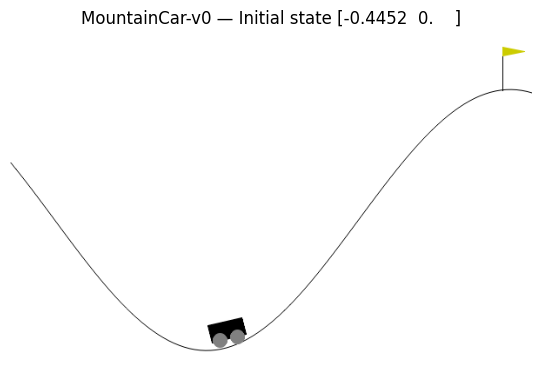

In [ ]:
# Show one environment frame.

render_env = gym.make("MountainCar-v0", render_mode="rgb_array")
state, _ = render_env.reset(seed=SEED)
frame = render_env.render()

plt.figure(figsize=(8, 4))
plt.imshow(frame)
plt.axis("off")
plt.title(f"MountainCar-v0 — Initial state {np.round(state, 4)}")
plt.tight_layout()
plt.show()

render_env.close()

## 31. RBF Feature Representation

A raw linear model using only position and velocity may be too simple because the useful value function is nonlinear over the state space.

We therefore transform the state through radial basis functions.

For RBF center $\mathbf c_j$:

$$\phi_j(s)=\exp\left(-\frac{1}{2}\left\|\frac{s-\mathbf c_j}{\boldsymbol\sigma}\right\|^2\right)$$

A feature is close to $1$ when the state is near its center and becomes smaller farther away.

The action value remains linear in the learned weights:

$$\boxed{\hat Q(s,a)=\mathbf w_a^T\boldsymbol\phi(s)}$$

This is an important distinction:

$$\boxed{\text{nonlinear features in the state, but linear learning in the weights}}$$

In [ ]:
class RBFFeatures:
    def __init__(self, low, high, n_position_centers=9, n_velocity_centers=9):
        self.low = np.asarray(low, dtype=float)
        self.high = np.asarray(high, dtype=float)

        p_centers = np.linspace(self.low[0], self.high[0], n_position_centers)
        v_centers = np.linspace(self.low[1], self.high[1], n_velocity_centers)
        P, V = np.meshgrid(p_centers, v_centers)
        self.centers = np.column_stack([P.ravel(), V.ravel()])

        p_spacing = p_centers[1] - p_centers[0]
        v_spacing = v_centers[1] - v_centers[0]
        self.sigma = np.array([1.25 * p_spacing, 1.25 * v_spacing])
        self.n_features = len(self.centers) + 1  # +1 bias feature

    def transform(self, state):
        state = np.asarray(state, dtype=float)
        scaled_diff = (state - self.centers) / self.sigma
        rbf = np.exp(-0.5 * np.sum(scaled_diff**2, axis=1))
        return np.concatenate(([1.0], rbf))

feature_map = RBFFeatures(env.observation_space.low, env.observation_space.high)

print("Number of RBF centers:", len(feature_map.centers))
print("Number of features including bias:", feature_map.n_features)
print("Weights for 3 actions:", feature_map.n_features * env.action_space.n)
print("Approximate float64 weight memory:", feature_map.n_features * env.action_space.n * 8, "bytes")

Number of RBF centers: 81
Number of features including bias: 82
Weights for 3 actions: 246
Approximate float64 weight memory: 1968 bytes


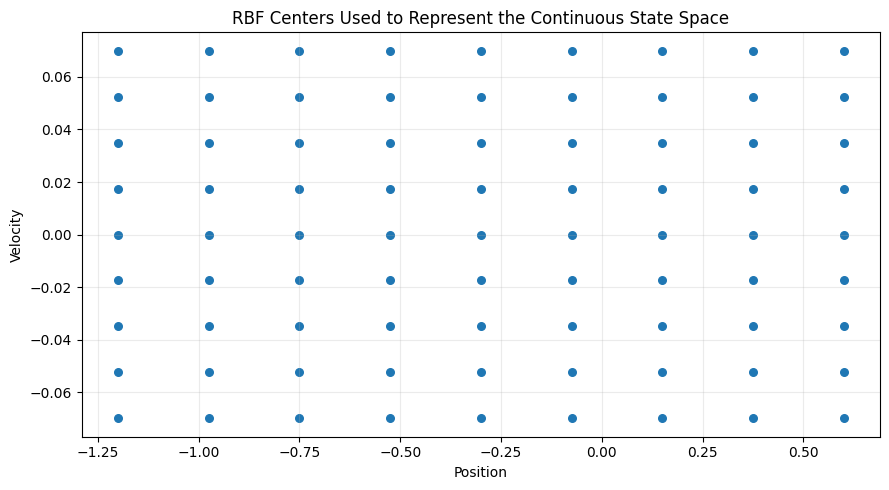

In [ ]:
# Visualize the RBF centers in the original state space.

plt.figure(figsize=(9, 5))
plt.scatter(feature_map.centers[:, 0], feature_map.centers[:, 1], s=30)
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("RBF Centers Used to Represent the Continuous State Space")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 32. Action-Value Model

For three actions, store a weight matrix:

$$\mathbf W\in\mathbb R^{3\times m}$$

where $m$ is the number of features.

For state $s$:

$$\boldsymbol\phi(s)=\text{RBF features of }s$$

All action values are calculated at once:

$$\boxed{\hat{\mathbf Q}(s)=\mathbf W\boldsymbol\phi(s)}$$

The row corresponding to the selected action is updated:

$$\boxed{\mathbf w_{A_t}\leftarrow\mathbf w_{A_t}+\alpha\delta_t\boldsymbol\phi(S_t)}$$

In [ ]:
def q_values(weights, phi):
    return weights @ phi

def epsilon_greedy(weights, phi, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(weights.shape[0]))
    return int(np.argmax(q_values(weights, phi)))

def epsilon_greedy_probabilities(q, epsilon):
    n_actions = len(q)
    probs = np.full(n_actions, epsilon / n_actions)
    probs[int(np.argmax(q))] += 1.0 - epsilon
    return probs

## 33. One Training Function for All Three Algorithms

The function below keeps the feature representation, learning rate, discount factor, exploration schedule, and environment structure the same.

Only the TD target changes.

### Q-Learning target

$$y_t=R_{t+1}+\gamma\max_a\hat Q(S_{t+1},a)$$

### SARSA target

$$y_t=R_{t+1}+\gamma\hat Q(S_{t+1},A_{t+1})$$

### Expected SARSA target

$$y_t=R_{t+1}+\gamma\sum_a\pi(a|S_{t+1})\hat Q(S_{t+1},a)$$

In [ ]:
def train_approximate_td(
    algorithm,
    n_episodes=2500,
    alpha=0.02,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.02,
    epsilon_decay=0.997,
    seed=42
):
    env_train = gym.make("MountainCar-v0")
    rng = np.random.default_rng(seed)
    n_actions = env_train.action_space.n
    weights = np.zeros((n_actions, feature_map.n_features), dtype=float)

    episode_rewards = []
    episode_lengths = []
    update_norms = []
    epsilons = []

    for episode in range(n_episodes):
        epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** episode))
        state, _ = env_train.reset(seed=seed + episode)
        phi = feature_map.transform(state)
        action = epsilon_greedy(weights, phi, epsilon, rng)

        total_reward = 0.0
        total_update_norm = 0.0

        for step in range(1, 201):
            next_state, reward, terminated, truncated, _ = env_train.step(action)
            done = terminated or truncated
            next_phi = feature_map.transform(next_state)

            q_current = weights[action] @ phi

            if done:
                target = reward
                next_action = None
            else:
                q_next = q_values(weights, next_phi)

                if algorithm == "q_learning":
                    target = reward + gamma * np.max(q_next)
                    next_action = epsilon_greedy(weights, next_phi, epsilon, rng)

                elif algorithm == "sarsa":
                    next_action = epsilon_greedy(weights, next_phi, epsilon, rng)
                    target = reward + gamma * q_next[next_action]

                elif algorithm == "expected_sarsa":
                    probs = epsilon_greedy_probabilities(q_next, epsilon)
                    target = reward + gamma * np.dot(probs, q_next)
                    next_action = epsilon_greedy(weights, next_phi, epsilon, rng)

                else:
                    raise ValueError("algorithm must be 'q_learning', 'sarsa', or 'expected_sarsa'")

            delta = target - q_current
            weight_change = alpha * delta * phi
            weights[action] += weight_change

            total_reward += reward
            total_update_norm += np.linalg.norm(weight_change)

            if done:
                break

            state = next_state
            phi = next_phi
            action = next_action

        episode_rewards.append(total_reward)
        episode_lengths.append(step)
        update_norms.append(total_update_norm)
        epsilons.append(epsilon)

    env_train.close()

    history = {
        "rewards": np.asarray(episode_rewards),
        "lengths": np.asarray(episode_lengths),
        "update_norms": np.asarray(update_norms),
        "epsilons": np.asarray(epsilons)
    }

    return weights, history

## 34. Train Approximate Q-Learning, SARSA, and Expected SARSA

The same feature map and hyperparameters are used for all three methods to make the comparison easier to interpret.

Because reinforcement-learning results are stochastic, exact curves will vary with the random seed and hyperparameters.

In [ ]:
N_EPISODES = 2500
ALPHA = 0.02
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.02
EPSILON_DECAY = 0.997

weights_ql, history_ql = train_approximate_td(
    "q_learning", N_EPISODES, ALPHA, GAMMA, EPSILON_START, EPSILON_END, EPSILON_DECAY, seed=SEED
)

weights_sarsa, history_sarsa = train_approximate_td(
    "sarsa", N_EPISODES, ALPHA, GAMMA, EPSILON_START, EPSILON_END, EPSILON_DECAY, seed=SEED
)

weights_esarsa, history_esarsa = train_approximate_td(
    "expected_sarsa", N_EPISODES, ALPHA, GAMMA, EPSILON_START, EPSILON_END, EPSILON_DECAY, seed=SEED
)

print("Training complete.")

Training complete.


## 35. Actual Reward vs Episode

MountainCar gives approximately `-1` per time step, so a less negative episode reward generally means the goal was reached in fewer steps.

The first plot uses the **actual episode reward**, not a moving average.

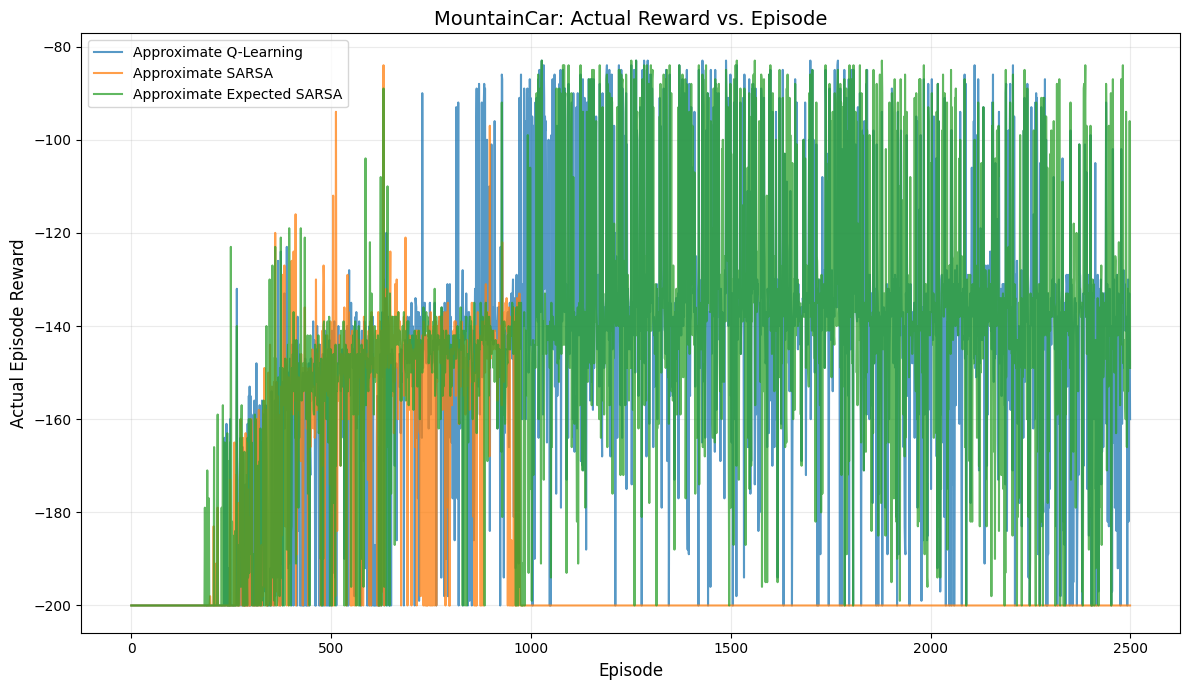

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(history_ql["rewards"], label="Approximate Q-Learning", alpha=0.75)
plt.plot(history_sarsa["rewards"], label="Approximate SARSA", alpha=0.75)
plt.plot(history_esarsa["rewards"], label="Approximate Expected SARSA", alpha=0.75)
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Actual Episode Reward", fontsize=12)
plt.title("MountainCar: Actual Reward vs. Episode", fontsize=14)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 36. Moving-Average Reward for the Learning Trend

Raw rewards should be kept because they show the real episode outcomes. A moving average is added separately to make the longer-term learning trend easier to see.

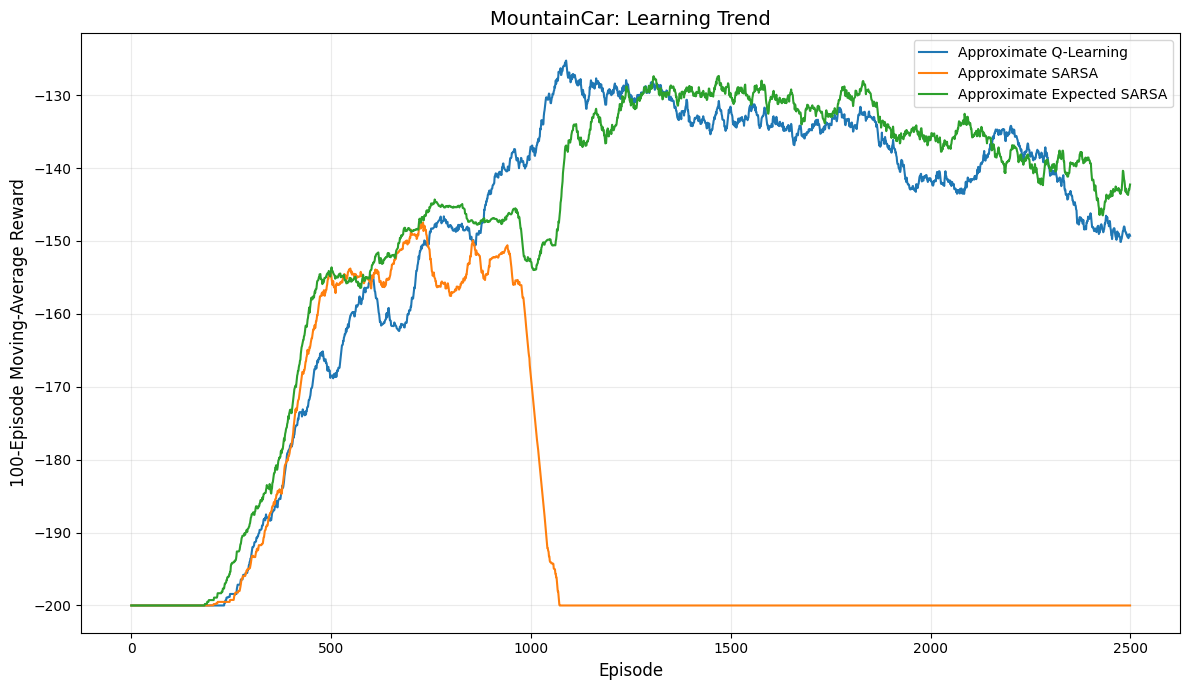

In [ ]:
def moving_average(values, window=100):
    return pd.Series(values).rolling(window, min_periods=1).mean().to_numpy()

window = 100

plt.figure(figsize=(12, 7))
plt.plot(moving_average(history_ql["rewards"], window), label="Approximate Q-Learning")
plt.plot(moving_average(history_sarsa["rewards"], window), label="Approximate SARSA")
plt.plot(moving_average(history_esarsa["rewards"], window), label="Approximate Expected SARSA")
plt.xlabel("Episode", fontsize=12)
plt.ylabel(f"{window}-Episode Moving-Average Reward", fontsize=12)
plt.title("MountainCar: Learning Trend", fontsize=14)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 37. Weight-Change Convergence View

A tabular notebook can track changes in the Q-table. Here the learned object is the parameter matrix $\mathbf W$, so a more appropriate quantity is the magnitude of the weight updates.

For an update:

$$\Delta\mathbf w_t=\alpha\delta_t\boldsymbol\phi(S_t)$$

we track its norm and accumulate it over each episode.

Smaller changes later in training can indicate that the parameter updates are becoming less dramatic, although stochastic RL does not require this curve to decrease monotonically.

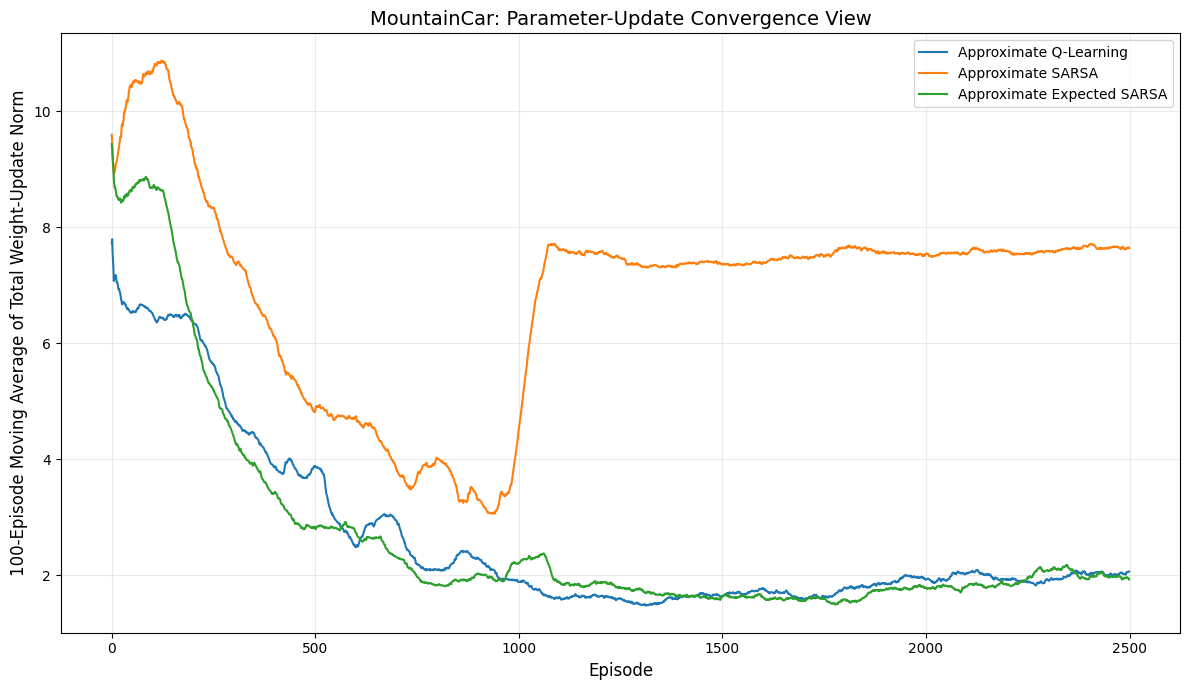

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(moving_average(history_ql["update_norms"], 100), label="Approximate Q-Learning")
plt.plot(moving_average(history_sarsa["update_norms"], 100), label="Approximate SARSA")
plt.plot(moving_average(history_esarsa["update_norms"], 100), label="Approximate Expected SARSA")
plt.xlabel("Episode", fontsize=12)
plt.ylabel("100-Episode Moving Average of Total Weight-Update Norm", fontsize=12)
plt.title("MountainCar: Parameter-Update Convergence View", fontsize=14)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 38. Greedy Evaluation

Training uses exploration. Evaluation should test the learned policy without exploratory actions.

For each state:

$$a_t=\arg\max_a\hat Q(S_t,a)$$

We evaluate each trained model over multiple episodes and report average reward, average episode length, and success rate.

In [ ]:
def evaluate_policy(weights, n_episodes=100, seed=1000):
    env_eval = gym.make("MountainCar-v0")
    rewards = []
    lengths = []
    successes = []

    for episode in range(n_episodes):
        state, _ = env_eval.reset(seed=seed + episode)
        total_reward = 0.0

        for step in range(1, 201):
            phi = feature_map.transform(state)
            action = int(np.argmax(q_values(weights, phi)))
            state, reward, terminated, truncated, _ = env_eval.step(action)
            total_reward += reward

            if terminated or truncated:
                successes.append(int(terminated))
                break

        rewards.append(total_reward)
        lengths.append(step)

    env_eval.close()
    return np.mean(rewards), np.std(rewards), np.mean(lengths), 100*np.mean(successes)

results = []
for name, weights in [
    ("Approximate Q-Learning", weights_ql),
    ("Approximate SARSA", weights_sarsa),
    ("Approximate Expected SARSA", weights_esarsa)
]:
    mean_reward, std_reward, mean_length, success_rate = evaluate_policy(weights)
    results.append({
        "Method": name,
        "Mean reward": mean_reward,
        "Reward SD": std_reward,
        "Mean episode length": mean_length,
        "Success rate (%)": success_rate
    })

results_df = pd.DataFrame(results)
results_df

,Method,Mean reward,Reward SD,Mean episode length,Success rate (%)
0,Approximate Q-Learning,-165.41,32.331438,165.41,63.0
1,Approximate SARSA,-200.00,0.000000,200.00,0.0
2,Approximate Expected SARSA,-122.70,25.824601,122.70,100.0


The evaluation table reports what happened in this particular experiment. It should not be interpreted as a universal ranking of the algorithms. Results depend on the environment, features, learning rate, exploration schedule, random seed, and training duration.

## 39. Learned State-Value Surface

For control, a useful visualization is:

$$\hat V_*(s)=\max_a\hat Q(s,a)$$

We evaluate this quantity over a grid of position and velocity values.

The next cell automatically chooses the trained model with the highest mean evaluation reward **in this run** only for visualization and rollout.

In [ ]:
weights_by_name = {
    "Approximate Q-Learning": weights_ql,
    "Approximate SARSA": weights_sarsa,
    "Approximate Expected SARSA": weights_esarsa
}

selected_name = results_df.loc[results_df["Mean reward"].idxmax(), "Method"]
selected_weights = weights_by_name[selected_name]

print("Model selected from this run for visualization:", selected_name)

Model selected from this run for visualization: Approximate Expected SARSA


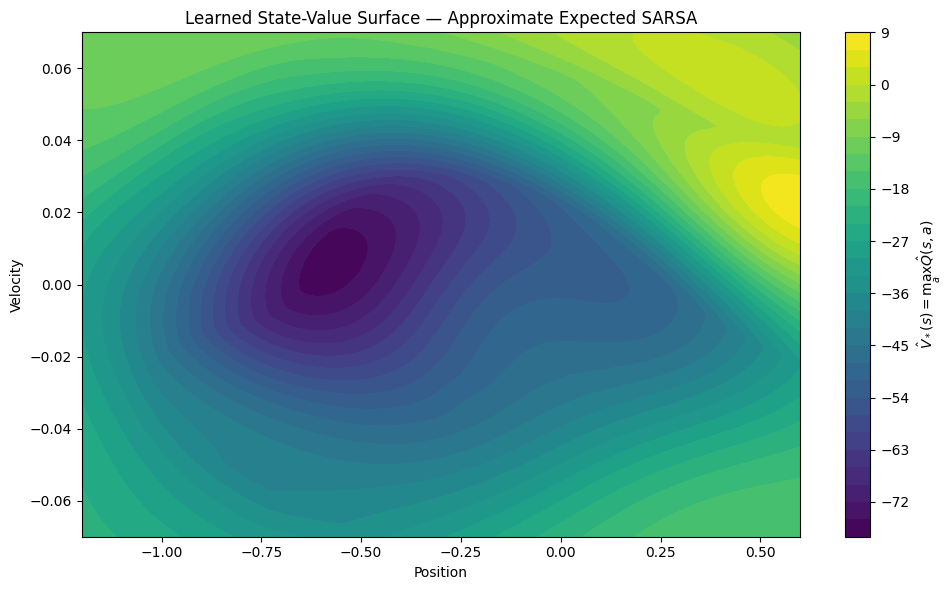

In [ ]:
position_values = np.linspace(env.observation_space.low[0], env.observation_space.high[0], 120)
velocity_values = np.linspace(env.observation_space.low[1], env.observation_space.high[1], 120)

value_surface = np.zeros((len(velocity_values), len(position_values)))

for i, velocity in enumerate(velocity_values):
    for j, position in enumerate(position_values):
        phi = feature_map.transform([position, velocity])
        value_surface[i, j] = np.max(q_values(selected_weights, phi))

plt.figure(figsize=(10, 6))
contour = plt.contourf(position_values, velocity_values, value_surface, levels=30)
plt.colorbar(contour, label=r"$\hat V_*(s)=\max_a \hat Q(s,a)$")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title(f"Learned State-Value Surface — {selected_name}")
plt.tight_layout()
plt.show()

## 40. Learned Greedy Policy Map

For each continuous state, the policy chooses:

$$\pi(s)=\arg\max_a\hat Q(s,a)$$

The policy map shows which action is preferred across the position-velocity state space.

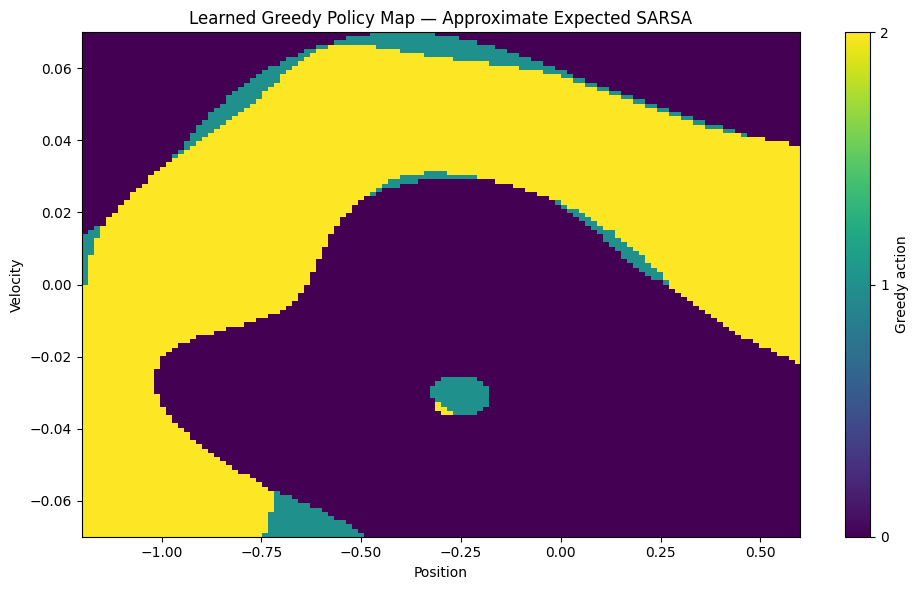

In [ ]:
policy_map = np.zeros((len(velocity_values), len(position_values)), dtype=int)

for i, velocity in enumerate(velocity_values):
    for j, position in enumerate(position_values):
        phi = feature_map.transform([position, velocity])
        policy_map[i, j] = int(np.argmax(q_values(selected_weights, phi)))

plt.figure(figsize=(10, 6))
image = plt.imshow(
    policy_map,
    origin="lower",
    aspect="auto",
    extent=[
        position_values.min(),
        position_values.max(),
        velocity_values.min(),
        velocity_values.max()
    ],
    interpolation="nearest"
)
plt.colorbar(image, ticks=[0, 1, 2], label="Greedy action")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title(f"Learned Greedy Policy Map — {selected_name}")
plt.tight_layout()
plt.show()

## 41. Create a GIF of the Learned Policy

This final demonstration runs the selected learned model greedily:

$$A_t=\arg\max_a\hat Q(S_t,a)$$

The agent is no longer consulting a Q-table. At every frame it:

1. receives the continuous state,
2. converts the state into RBF features,
3. multiplies those features by learned weights,
4. obtains three approximate Q-values,
5. selects the action with the largest value.

Method: Approximate Expected SARSA
Reward: -133.0
Steps: 133
Reached goal: True


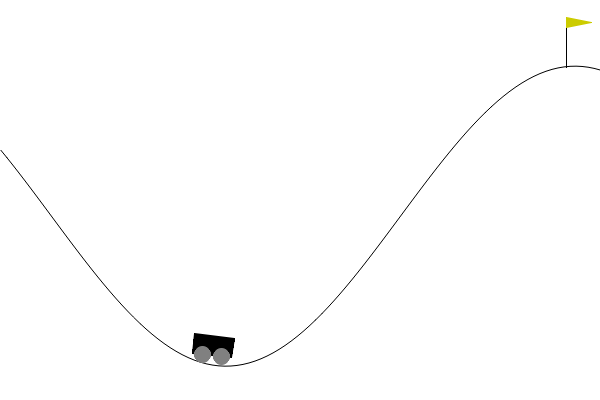

In [ ]:
def record_greedy_episode(weights, filename="mountaincar_vfa.gif", seed=2026):
    env_video = gym.make("MountainCar-v0", render_mode="rgb_array")
    state, _ = env_video.reset(seed=seed)
    frames = [env_video.render()]
    total_reward = 0.0

    for step in range(1, 201):
        phi = feature_map.transform(state)
        action = int(np.argmax(q_values(weights, phi)))
        state, reward, terminated, truncated, _ = env_video.step(action)
        total_reward += reward
        frames.append(env_video.render())

        if terminated or truncated:
            break

    env_video.close()
    imageio.mimsave(filename, frames, fps=30, loop=0)
    return filename, total_reward, step, terminated

gif_file, gif_reward, gif_steps, gif_success = record_greedy_episode(selected_weights)

print("Method:", selected_name)
print("Reward:", gif_reward)
print("Steps:", gif_steps)
print("Reached goal:", gif_success)

display(Image(filename=gif_file))

# 42. What Exactly Is Stored After Training?

This is worth stating explicitly.

A tabular agent would store something conceptually like:

$$Q[s_1,0],Q[s_1,1],Q[s_1,2],Q[s_2,0],Q[s_2,1],Q[s_2,2],\ldots$$

The VFA agent stores:

$$\boxed{\mathbf W}$$

When a new state arrives, it calculates:

$$\boldsymbol\phi(s)=\text{features of the new state}$$

then:

$$\boxed{\hat{\mathbf Q}(s)=\mathbf W\boldsymbol\phi(s)}$$

and chooses:

$$\boxed{a^*=\arg\max_a\hat Q(s,a)}$$

The state does **not** need its own pre-existing row in a lookup table.

# 43. Final Concept Map

The progression in this notebook is:

$$\boxed{\text{Large/continuous state space}\rightarrow\text{features}\rightarrow\text{parameterized value function}\rightarrow\text{loss}\rightarrow\text{gradient}\rightarrow\text{weight update}\rightarrow\text{generalization}}$$

For linear action-value approximation:

$$\boxed{\hat Q(s,a)=\mathbf w_a^T\boldsymbol\phi(s)}$$

For one TD transition:

$$\boxed{\delta_t=y_t-\hat Q(S_t,A_t)}$$

For linear semi-gradient learning:

$$\boxed{\mathbf w_{A_t}\leftarrow\mathbf w_{A_t}+\alpha\delta_t\boldsymbol\phi(S_t)}$$

The three TD control algorithms differ mainly in how they construct $y_t$:

$$\boxed{Q\text{-Learning: }y_t=R_{t+1}+\gamma\max_a\hat Q(S_{t+1},a)}$$

$$\boxed{SARSA: }y_t=R_{t+1}+\gamma\hat Q(S_{t+1},A_{t+1})}$$

$$\boxed{\text{Expected SARSA: }y_t=R_{t+1}+\gamma\sum_a\pi(a|S_{t+1})\hat Q(S_{t+1},a)}$$

# 44. Bridge to Deep Reinforcement Learning

Value function approximation leads naturally to deep reinforcement learning.

A linear approximator uses:

$$\hat Q(s,a;\mathbf w)=\mathbf w_a^T\boldsymbol\phi(s)$$

A neural-network approximator uses:

$$\hat Q(s,a;\boldsymbol\theta)=\text{NeuralNetwork}(s;\boldsymbol\theta)$$

The central idea remains the same:

$$\boxed{\text{state}\rightarrow\text{parameterized model}\rightarrow\text{predicted value}\rightarrow\text{target}\rightarrow\text{loss}\rightarrow\text{parameter update}}$$

A later DQN notebook can build directly on this foundation by replacing the linear feature model with a neural network and adding techniques used to stabilize deep Q-learning.